/tmp/ipykernel_276500/3403428769.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  robust_df = metrics_df.set_index("Metric")[["MultiResolution", "RobustDMC"]].replace({True:1, False:0})


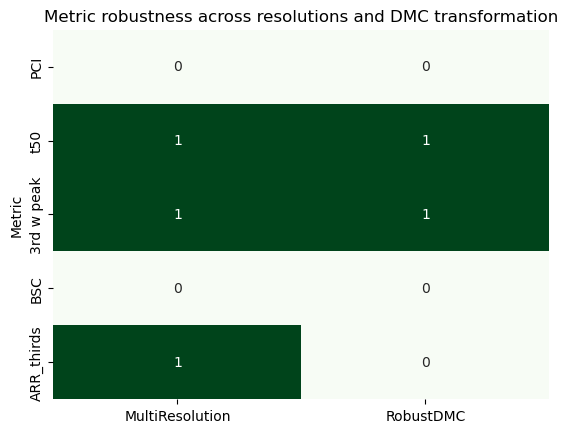

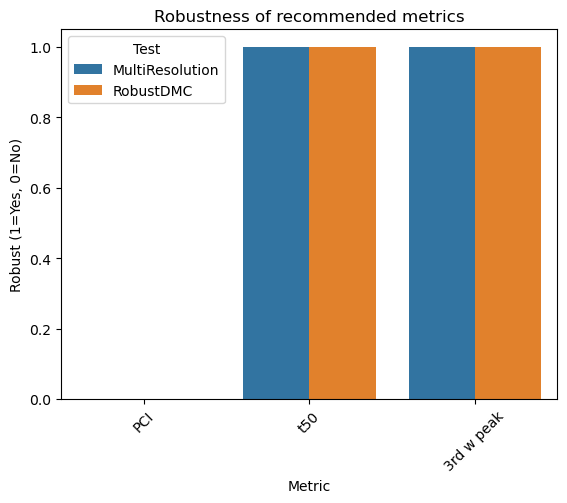

,Metric,Recommended,MultiResolution,RobustDMC,Notes,Score
1,t50,True,True,True,Measures median timing,3
2,3rd w peak,True,True,True,Peak detected in DMC works well,3
0,PCI,True,False,False,Intensity contrast reduced by smoothing,1
4,ARR_thirds,False,True,False,Sensitive to DMC,1
3,BSC,False,False,False,Sensitive to representation,0


In [1]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["PCI", "t50", "3rd w peak", "BSC", "ARR_thirds"],
    "Recommended": [True, True, True, False, False],
    "MultiResolution": [False, True, True, False, True],
    "RobustDMC": [False, True, True, False, False],
    "Notes": ["Intensity contrast reduced by smoothing", 
              "Measures median timing", 
              "Peak detected in DMC works well", 
              "Sensitive to representation", 
              "Sensitive to DMC"]
})

import seaborn as sns
import matplotlib.pyplot as plt

robust_df = metrics_df.set_index("Metric")[["MultiResolution", "RobustDMC"]].replace({True:1, False:0})
sns.heatmap(robust_df, annot=True, cmap="Greens", cbar=False)
plt.title("Metric robustness across resolutions and DMC transformation")
plt.show()

recommended = metrics_df[metrics_df["Recommended"]]
recommended_melt = recommended.melt(id_vars="Metric", value_vars=["MultiResolution", "RobustDMC"], 
                                    var_name="Test", value_name="Robust")
sns.barplot(data=recommended_melt, x="Metric", y="Robust", hue="Test")
plt.xticks(rotation=45)
plt.ylabel("Robust (1=Yes, 0=No)")
plt.title("Robustness of recommended metrics")
plt.show()

metrics_df["Score"] = metrics_df["Recommended"].astype(int) + \
                      metrics_df["MultiResolution"].astype(int) + \
                      metrics_df["RobustDMC"].astype(int)
metrics_df.sort_values("Score", ascending=False)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

data=pd.read_csv("Data/CreatingSummaryFig.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Data/CreatingSummaryFig.csv'

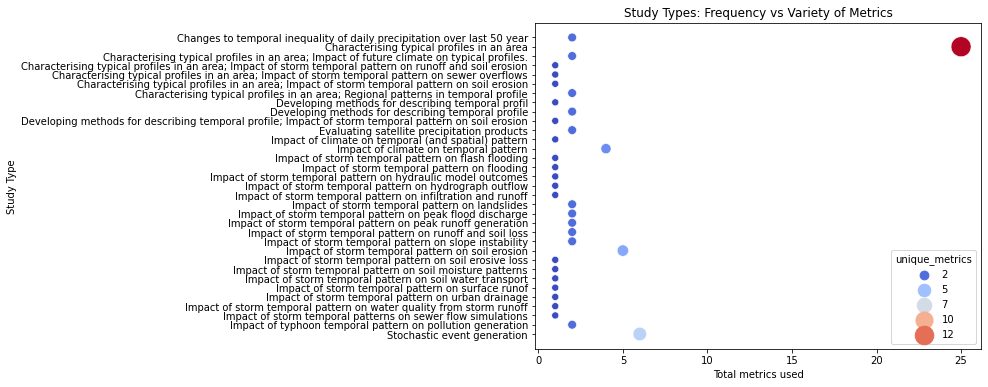

In [3]:
study_diversity = data.groupby('Study type').agg(
    total_metrics=('Metric name','count'),
    unique_metrics=('Metric name','nunique')
).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=study_diversity,
    x="total_metrics", y="Study type",
    size="unique_metrics", sizes=(50,400),
    hue="unique_metrics", palette="coolwarm", legend="brief"
)
plt.xlabel("Total metrics used")
plt.ylabel("Study Type")
plt.title("Study Types: Frequency vs Variety of Metrics")
plt.show()


In [5]:
# plt.figure(figsize=(8,6))
# sns.barplot(y=subset['Metric name'].value_counts().index,
#             x=subset['Metric name'].value_counts().values,
#             palette="tab10")
# plt.xlabel("Frequency")
# plt.ylabel("Metric")
# plt.title("Metrics in: Characterising typical profiles in an area")
# plt.show()


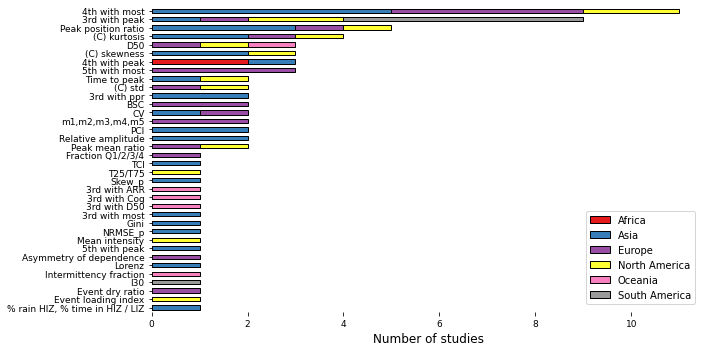

In [7]:
region_map = {"United Kingdom": "Europe",
    "Germany": "Europe",
    "Italy": "Europe",
    "Poland": "Europe",    
    "Spain": "Europe",
    "Greece": "Europe",
    "Poland": "Europe",
    "Slovenia": "Europe",
    "United States of America": "North America",
    "South Africa": "Africa",
    "China": "Asia",
    "South Korea": "Asia",
    "Malaysia": "Asia",
    "Australia": "Oceania",
    "Brazil": "South America", 
    "Peru": "South America",
    "Iraq": "Asia"}

# Add a new column for region
data['region'] = data['Country'].map(region_map)

# Count occurrences of each metric by region
metric_region = data.groupby(['Metric name', 'region']).size().reset_index(name='count')

# Pivot to wide format for stacked bars
pivot_table = metric_region.pivot(index='Metric name', columns='region', values='count').fillna(0)

# Sort metrics by total count
pivot_table = pivot_table.loc[pivot_table.sum(axis=1).sort_values(ascending=True).index]

region_colors = {
    "Europe": "#4daf4a",       # bright red
    "Asia": "#377eb8",         # vivid blue
    "North America": "gold",# bright green
    "Oceania": "#ff7f00",     # orange
    'Africa':'darkred',
    'South America':'orange',    
    'Middle East':'purple'}

fig,ax=plt.subplots(figsize=(15,10))
# Plot stacked horizontal bar chart
pivot_table.plot(kind='barh',
                 ax=ax,
                 stacked=True,
                 figsize=(10, 5),
                 edgecolor='black',
#                  color=[region_colors[col] for col in pivot_table.columns]
                 colormap='Set1'
                )  # nice qualitative palette

ax.tick_params(axis='both', which='major', labelsize=9)
plt.xlabel("Number of studies", fontsize=12)
plt.ylabel("")
# plt.title("Frequency of Metrics by World Region")
plt.legend(bbox_to_anchor=(0.99, 0.01), loc='lower right')
plt.tight_layout()
ax.set_frame_on(False)
fig.savefig('Figures/metrics_summary.jpg', dpi=300)

In [ ]:
# Load world map
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Count metrics per country
country_counts = data.groupby("Country").size().reset_index(name="count")

# Merge into world basemap
world = world.merge(country_counts, left_on="name", right_on="Country", how="left")

# Plot: first the base map in light grey for missing values
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
world[world["count"].isna()].plot(ax=ax, color="white", edgecolor="black")  # missing countries
world[~world["count"].isna()].plot(column="count", cmap="OrRd", legend=True, ax=ax, edgecolor="black")

ax.set_title("Number of Metrics Reported per Country")
ax.axis("off")
plt.show()

In [ ]:
purpose_diversity = data.groupby('Country').agg(
    studies=('Metric name','count'),
    unique_metrics=('Metric name','nunique')
).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=purpose_diversity,
    x="studies", y="Country",
    size="unique_metrics", sizes=(50,400),
    hue="unique_metrics", palette="coolwarm", legend="brief"
)
plt.xlabel("Number of studies")
plt.ylabel("Study Purpose")
plt.title("Study Purposes: Frequency vs Diversity of Metrics")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of each metric by country
metric_country = data.groupby(['Metric name', 'Country']).size().reset_index(name='count')

# Pivot to wide format for stacked bars
pivot_table = metric_country.pivot(index='Metric name', columns='Country', values='count').fillna(0)

# Sort metrics by total count
pivot_table = pivot_table.loc[pivot_table.sum(axis=1).sort_values(ascending=False).index]

# Plot stacked horizontal bar chart
pivot_table.plot(kind='barh',
                 stacked=True,
                 figsize=(10, 8),
                 colormap='tab20')

plt.xlabel("Number of studies")
plt.title("Frequency of Metrics by Country")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
country_metric = data.groupby(['Country','Metric type']).size().reset_index(name='count')
pivot_table = country_metric.pivot(index='Country', columns='Metric type', values='count').fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.title("Use of Metric Types by Country")
plt.ylabel("Country")
plt.xlabel("Metric Type")
plt.show()


In [ ]:
study_metric = data.groupby(['Study type','Metric type']).size().reset_index(name='count')
pivot_table2 = study_metric.pivot(index='Study type', columns='Metric type', values='count').fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table2, annot=True, cmap="OrRd", cbar_kws={'label': 'Count'})
plt.title("Use of Metric Types by Study Type")
plt.ylabel("Study Type")
plt.xlabel("Metric Type")
plt.show()
